# Temperature dependent elastic constants

## Background

$$C_{ijkl} = \frac{1}{V} \frac{\partial^2 U}{\partial \varepsilon_{ij}\partial \varepsilon_{kl}}$$

$$U(T) = \frac{V}{2}C_{ijkl}(T)\varepsilon_{ij}\varepsilon_{kl}$$

$$\sigma_{ij} = C_{ijkl}{\varepsilon_{kl}}$$

### How to get $U$ or $\sigma$

- MD
- Quasi-Harmonic

## Tasks

- Get $a_0$ from potential
- Lattice parameter (as a function of T)
  - MD
    - NVT
    - NPT
  - QH
- Calculate $U$ or $\sigma$ for various $\varepsilon$
  - MD: Equilibriate and average with LAMMPS
  - QH: Get strains from Yuriy's tool and run phonopy
- Fit

## Teams

- MD: Erik, Han, (Raynol), Prabhath, Jan, Sriram
- QH: Raynol, (Sam), Bharathi, Ahmed, Haitham
- Fit & Yuriy: Sam
- Literature

# Implementation

* https://atomistics.readthedocs.io/en/latest/bulk_modulus_with_gpaw.html#elastic-matrix
* https://github.com/pyiron/atomistics/blob/main/tests/test_elastic_lammpslib_functional.py
* https://github.com/pyiron/pyiron_workflow_atomistics/blob/interstitials/pyiron_workflow_atomistics/dataclass_storage.py
* https://github.com/ligerzero-ai/pyiron_workflow_lammps/blob/main/pyiron_workflow_lammps/engine.py#L21

## Reference

We compare our values with the paper - [M. Krief, et. al., Physical Review E, 103, 063307, 2021](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.103.063307#s4)

Potential used: Copper [Mishin potential](https://www.ctcms.nist.gov/potentials/entry/2001--Mishin-Y-Mehl-M-J-Papaconstantopoulos-D-A-et-al--Cu-1/)

## Imports

In [1]:
from ase.build import bulk
from ase.atoms import Atoms

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from __future__ import annotations

from atomistics.workflows.elastic.workflow import (
    get_tasks_for_elastic_matrix,
    analyse_results_for_elastic_matrix
)

from atomistics.calculators import (
    evaluate_with_lammpslib, 
    get_potential_by_name, 
    calc_molecular_dynamics_npt_with_lammpslib, 
    calc_molecular_dynamics_nvt_with_lammpslib
)

from atomistics.calculators.lammps.libcalculator import (
    calc_static_with_lammpslib, 
    calc_molecular_dynamics_langevin_with_lammpslib
)

/cmmc/ptmp/pyironhb/pyiron_latest_env/lib/python3.12/site-packages/atomistics/calculators/__init__.py:63: UserWarning: calc_static_with_qe(), evaluate_with_qe() and optimize_positions_and_volume_with_qe() are not available as the import of the module named 'pwtools' failed.
  raise_warning(module_list=quantum_espresso_function, import_error=e)


In [3]:
from pyiron_base import Project, job

In [4]:
pr = Project("Convergence_Studies_MD_Elastic_Constants")

## Create bulk sample with a guessed lattice constant

In [5]:
unit_cell = bulk('Cu', 'fcc', a=3.6514, cubic=True) # 4 atoms

In [6]:
repeated_unit_cell = unit_cell.repeat(5) # 500 atoms

In [7]:
potential_name_str = "2001--Mishin-Y--Cu-1--LAMMPS--ipr1"

potential_df = get_potential_by_name(
    potential_name=potential_name_str
)

## 0K Relaxed Structure

In [8]:
def get_relaxed_structure_at_0K(
        structure: Atoms, 
        potential: str, 
        lmp_optimizer_kwargs : dict = None
        ) -> Atoms:
    
    df_pot_selected = get_potential_by_name(
        potential_name=potential
        )
    
    result_dict = evaluate_with_lammpslib(
        task_dict={"optimize_positions_and_volume": structure},
        potential_dataframe=df_pot_selected,
        lmp_optimizer_kwargs=lmp_optimizer_kwargs
        )
    
    structure_relaxed = result_dict['structure_with_optimized_positions_and_volume']

    return structure_relaxed

In [9]:
lmp_optimizer_kwargs={
    'min_style':'cg',
    'ionic_force_tolerance':1e-8,
    'pressure':np.zeros(6) # add anisotropy
}

In [10]:
relaxed_unit_cell = get_relaxed_structure_at_0K(
    unit_cell, # 4 atoms
    potential_name_str, 
    lmp_optimizer_kwargs
)

relaxed_unit_cell # 4 atoms

Atoms(symbols='Cu4', pbc=True, cell=[3.61500008107858, 3.61500008107858, 3.6150000810785805])

## 0K Lattice Constant

In [11]:
def get_lattice_constant_at_0K(
        structure: Atoms, 
        potential: str, 
        lmp_optimizer_kwargs : dict = None
        ) -> float:

    structure_relaxed = get_relaxed_structure_at_0K(
        structure=structure, 
        potential=potential,
        lmp_optimizer_kwargs=lmp_optimizer_kwargs
    )
    
    a_0 = structure_relaxed.get_volume()**(1/3)

    return a_0 # Angstrom

In [12]:
a_0 = get_lattice_constant_at_0K(
    structure=unit_cell, 
    potential=potential_name_str,
    lmp_optimizer_kwargs=lmp_optimizer_kwargs)

a_0 # Angstrom

np.float64(3.61500008107858)

We get the same lattice constant at 0K as the reference paper!

## 0K Elastic Constants

In [13]:
def get_strain_tensor_cubic(
        structure : Atoms, 
        strain : float = 0.005
    ) -> dict:

    deformation_gradient_dict = {
        'C11': np.eye(3,3) + np.array([[ strain,      0,      0], 
                                       [      0,      0,      0],
                                       [      0,      0,      0]]),
        'C12': np.eye(3,3) + np.array([[ strain,      0,      0], 
                                       [      0, strain,      0], 
                                       [      0,      0,      0]]),
        'C44': np.eye(3,3) + np.array([[      0,      0,      0], 
                                       [      0,      0, strain], 
                                       [      0, strain,      0]])
    }

    return deformation_gradient_dict

In [14]:
def get_elastic_constants_from_stress_tensor(
        tensor_dict : dict, 
        strain : float
    ) -> list[float]:

    elastic_constants_list = []

    for constant_str, diff in tensor_dict.items():
        if constant_str == 'C11':
            constant = diff[0, 0] / strain
            elastic_constants_list.append(abs(constant))

        elif constant_str == 'C12':
            sigma33 = diff[2, 2]
            constant = (sigma33/ strain) / 2
            elastic_constants_list.append(abs(constant))

        elif constant_str == 'C44':
            sigma23 = diff[2, 1]
            constant = sigma23 / (2 * strain)
            elastic_constants_list.append(abs(constant))

    return elastic_constants_list

In [15]:
def get_stress_tensor_at_0K(
        structure : Atoms, 
        potential_dataframe : pd.DataFrame, 
        deformation_gradient : np.array
    ):
    
    structure_strained = structure.copy()
    relaxed_cell = np.array(structure_strained.get_cell().tolist())

    strained_cell = deformation_gradient@relaxed_cell
    structure_strained.set_cell(
        strained_cell, 
        scale_atoms=True
    )
    
    relaxed_dict = calc_static_with_lammpslib(
        structure=structure, 
        potential_dataframe=potential_dataframe
    )
    strained_dict = calc_static_with_lammpslib(
        structure=structure_strained,
        potential_dataframe=potential_dataframe
    )

    relaxed_dict['stress_GPa'] = relaxed_dict['stress'] / 10**4
    strained_dict['stress_GPa'] = strained_dict['stress'] / 10**4

    stress_diff = strained_dict['stress_GPa'] - relaxed_dict['stress_GPa']
    
    return stress_diff, relaxed_dict, strained_dict

In [16]:
def calculate_elastic_constants_at_0K(
        structure : Atoms, 
        potential_name : str,
        strain : float = 0.005
    ):

    df_pot_selected = get_potential_by_name(
        potential_name=potential_name
    )

    deformation_gradient_dict = get_strain_tensor_cubic(
        structure=structure, 
        strain=strain
    )
    
    tensor_dict = {}
    for constant_str, deformation_gradient in deformation_gradient_dict.items():
        diff, relaxed_dict, strained_dict = get_stress_tensor_at_0K(
            structure=structure,
            potential_dataframe=df_pot_selected,
            deformation_gradient=deformation_gradient
        )
        
        tensor_dict[constant_str] = diff
        tensor_dict[f'relaxed_dict_{constant_str}'] = relaxed_dict
        tensor_dict[f'strained_dict_{constant_str}'] = strained_dict
    
    elastic_constants_list = get_elastic_constants_from_stress_tensor(
        tensor_dict=tensor_dict, 
        strain=strain
    )

    return elastic_constants_list, tensor_dict

## Reference function to fit elastic constants (Jan + Yury)'s

Requires only `relaxed_unit_cell` and `potential_name_str` from previous cells

In [17]:
def fit_elastic_constants(
        structure: Atoms, 
        potential: str, 
        strains, 
        stresses=None, 
        energies=None):

    task_dict, sym_dict = get_tasks_for_elastic_matrix(
        structure=structure,
        eps_range=0.005,
        num_of_point=5,
        zero_strain_job_name="s_e_0",
        sqrt_eta=True
    )

    potential_df = get_potential_by_name(
        potential_name=potential
    )

    result_dict = evaluate_with_lammpslib(
        task_dict=task_dict,
        potential_dataframe=potential_df,
    )
    
    elastic_dict, sym_dict = analyse_results_for_elastic_matrix(
        output_dict=result_dict,
        sym_dict=sym_dict,
        fit_order=2,
        zero_strain_job_name="s_e_0",
    )

    return elastic_dict

In [18]:
elastic_dict = fit_elastic_constants(
    structure=relaxed_unit_cell,
    potential=potential_name_str,
    strains=None
)

In [19]:
elastic_dict['elastic_matrix']

array([[169.74837327, 123.55258251, 123.55258251,   0.        ,
          0.        ,   0.        ],
       [123.55258251, 169.74837327, 123.55258251,   0.        ,
          0.        ,   0.        ],
       [123.55258251, 123.55258251, 169.74837327,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  76.24914297,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
         76.24914297,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,  76.24914297]])

In [20]:
elastic_constants_list_reference = [
    elastic_dict['elastic_matrix'][0,0], 
    elastic_dict['elastic_matrix'][0,1], 
    elastic_dict['elastic_matrix'][3,3]
    ]

np.round(elastic_constants_list_reference, 1) # GPa

array([169.7, 123.6,  76.2])

In comparison with the [reference paper](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.103.063307#s4 "M. Krief, et. al., Physical Review E, 103, 063307, 2021"),

$C_{11}$=169.9GPa, $C_{12}$=122.6GPa, and $C_{44}$=76.2GPa

## Finite Temperature equlibiration
* First run NPT to relax volume
* Then equilibriate the cell by running NVT

In [21]:
def equilibriate_structure_at_finite_temperature(
        structure : Atoms, 
        potential : str, 
        temperature : float = 500,
        run : int = 100000,
        thermo : int = 100,
        seed : int = 4928459, 
        cell_scale_value : int = 5,
        thermostat : str = 'langevin'
    ) -> Atoms:

    df_pot_selected = get_potential_by_name(
        potential_name=potential
    )
    
    structure_repeated = structure.repeat(cell_scale_value)

    npt_dict = calc_molecular_dynamics_npt_with_lammpslib(
        structure=structure_repeated,
        potential_dataframe=df_pot_selected,
        Tstart=temperature,
        Tstop=temperature,
        run=run,
        thermo=thermo,
        seed=seed
    )
    
    npt_lattice_constant = (np.mean(npt_dict['volume'][20:]/len(structure_repeated))*len(structure))**(1/3)
    
    # FIXME: Make it for a generic element - something might be wrong here. Need to check error propagation
    # structure_npt = bulk('Cu', a=npt_lattice_constant, cubic=True)
    # structure_repeated_npt = structure_npt.repeat(cell_scale_value)
    
    structure_repeated_npt = structure.copy()
    structure_repeated_npt.set_cell(
        [[npt_lattice_constant,0,0], 
         [0,npt_lattice_constant,0], 
         [0,0,npt_lattice_constant]],
        scale_atoms = True
    )
    structure_repeated_npt = structure_repeated_npt.repeat(cell_scale_value)

    if thermostat == 'nose-hoover':
        nvt_dict = calc_molecular_dynamics_nvt_with_lammpslib(
            structure=structure_repeated_npt,
            potential_dataframe=df_pot_selected,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed
        )
        
    elif thermostat == 'langevin':
        nvt_dict = calc_molecular_dynamics_langevin_with_lammpslib(
            structure=structure_repeated_npt,
            potential_dataframe=df_pot_selected,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed
        )
        
    structure_repeated_nvt = structure_repeated_npt.copy()
    structure_repeated_nvt.set_cell(
        nvt_dict['cell'][-1]
    )
    structure_repeated_nvt.set_positions(
        nvt_dict['positions'][-1]
    )
    structure_repeated_nvt.set_velocities(
        nvt_dict['velocities'][-1]
    )

    return structure_repeated_nvt

## Temperature-dependent Elastic Constants

In [22]:
def get_stress_tensor_at_finite_temperature(
        structure : Atoms, 
        potential_dataframe : pd.DataFrame, 
        deformation_gradient : np.array, 
        temperature : float,
        run : int, 
        thermo : int,
        seed : int,
        thermostat : str
    ):
    
    structure_strained = structure.copy()
    relaxed_cell = np.array(structure_strained.get_cell().tolist())

    strained_cell = deformation_gradient@relaxed_cell
    structure_strained.set_cell(
        strained_cell, 
        scale_atoms=True
    )
    
    if thermostat == 'nose-hoover':
        relaxed_dict = calc_molecular_dynamics_nvt_with_lammpslib(
            structure=structure, 
            potential_dataframe=potential_dataframe,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed,
            disable_initial_velocity=True
        )
        strained_dict = calc_molecular_dynamics_nvt_with_lammpslib(
            structure=structure_strained, 
            potential_dataframe=potential_dataframe,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed,
            disable_initial_velocity=True
        )
    
    elif thermostat == 'langevin':
        relaxed_dict = calc_molecular_dynamics_langevin_with_lammpslib(
            structure=structure, 
            potential_dataframe=potential_dataframe,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed,
            disable_initial_velocity=True
        )
        strained_dict = calc_molecular_dynamics_langevin_with_lammpslib(
            structure=structure_strained, 
            potential_dataframe=potential_dataframe,
            Tstart=temperature,
            Tstop=temperature,
            run=run,
            thermo=thermo,
            seed=seed,
            disable_initial_velocity=True
        )

    relaxed_dict['pressure_GPa'] = relaxed_dict['pressure'] / 10**4
    strained_dict['pressure_GPa'] = strained_dict['pressure'] / 10**4

    stress_diff = -np.mean(strained_dict['pressure_GPa'][20:] - relaxed_dict['pressure_GPa'][20:], axis=0)

    return stress_diff, relaxed_dict, strained_dict

Implement [Mean Measure value](https://github.com/pyiron/pyiron_atomistics/blob/c469a6ecbb787291dcc957f348cf74446fdc7ddc/pyiron_atomistics/lammps/control.py#L704) from pyiron_atomistics maybe?

In [23]:
def calculate_elastic_constants_at_finite_temperature(
        structure : Atoms, # change to unit cell
        cell_scale_value : int,
        potential_name : str, 
        temperature : float = 0, 
        strain : float = 0.005,
        run : int = 10000,
        thermo : int = 100, 
        seed : int = 42, 
        thermostat : str = 'langevin'
    ):

    df_pot_selected = get_potential_by_name(
        potential_name=potential_name
    )

    equilibriated_structure = equilibriate_structure_at_finite_temperature(
        structure=structure,
        potential=potential_name_str, 
        temperature=temperature, 
        seed=seed,
        cell_scale_value=cell_scale_value
    )
    
    deformation_gradient_dict = get_strain_tensor_cubic(
        structure=equilibriated_structure, 
        strain=strain
    )
    
    tensor_dict = {}
    for constant_str, deformation_gradient in deformation_gradient_dict.items():
        diff, relaxed_dict, strained_dict = get_stress_tensor_at_finite_temperature(
            structure=equilibriated_structure, 
            potential_dataframe=df_pot_selected,
            deformation_gradient=deformation_gradient,
            temperature=temperature,
            run=run,
            thermo=thermo,
            seed=seed,
            thermostat=thermostat
        )
        
        tensor_dict[constant_str] = diff
        tensor_dict[f'relaxed_dict_{constant_str}'] = relaxed_dict
        tensor_dict[f'strained_dict_{constant_str}'] = strained_dict
    
    elastic_constants_list = get_elastic_constants_from_stress_tensor(
        tensor_dict=tensor_dict, 
        strain=strain
    )

    return {"elastic_constants": elastic_constants_list, "tensor_dict": tensor_dict}

In [24]:
unit_cell = bulk('Cu', 'fcc', a=3.6514, cubic=True) # 4 atoms

In [25]:
repeated_unit_cell = unit_cell.repeat(5) # 500 atoms

In [26]:
potential_name_str = "2001--Mishin-Y--Cu-1--LAMMPS--ipr1"

potential_df = get_potential_by_name(
    potential_name=potential_name_str
)

In [28]:
equilibriated_structure = equilibriate_structure_at_finite_temperature(
    structure=unit_cell,
    potential=potential_name_str, 
    temperature=500, 
    seed=1234,
    cell_scale_value=1
)

In [29]:
deformation_gradient_dict = get_strain_tensor_cubic(
    structure=equilibriated_structure, 
    strain=0.0005
)

In [31]:
deformation_gradient_dict['C11']

array([[1.0005, 0.    , 0.    ],
       [0.    , 1.    , 0.    ],
       [0.    , 0.    , 1.    ]])

In [32]:
structure_strained = equilibriated_structure.copy()
relaxed_cell = np.array(structure_strained.get_cell().tolist())

strained_cell = deformation_gradient_dict['C11']@relaxed_cell
structure_strained.set_cell(
    strained_cell, 
    scale_atoms=True
)

In [34]:
relaxed_dict = calc_molecular_dynamics_langevin_with_lammpslib(
    structure=equilibriated_structure, 
    potential_dataframe=potential_df,
    Tstart=500,
    Tstop=500,
    run=1000,
    thermo=1,
    seed=1234,
    disable_initial_velocity=True
)
strained_dict = calc_molecular_dynamics_langevin_with_lammpslib(
    structure=structure_strained, 
    potential_dataframe=potential_df,
    Tstart=500,
    Tstop=500,
    run=1000,
    thermo=1,
    seed=1234,
    disable_initial_velocity=True
)

In [36]:
relaxed_dict

{'positions': array([[[3.43798166, 2.54167633, 1.45397387],
         [3.40329879, 0.59840346, 3.42034454],
         [1.52104155, 2.40553981, 3.21954082],
         [1.53907334, 0.52396544, 1.57551651]],
 
        [[3.4360715 , 2.53517228, 1.45290129],
         [3.40669305, 0.59738564, 3.41856968],
         [1.52149946, 2.40561281, 3.21637509],
         [1.53641213, 0.51999881, 1.57551442]],
 
        [[3.43376239, 2.52873618, 1.45152951],
         [3.41023189, 0.59672367, 3.41674394],
         [1.52212652, 2.4055246 , 3.21323709],
         [1.53388042, 0.5162087 , 1.57540503]],
 
        ...,
 
        [[3.30672084, 2.06022582, 1.29666596],
         [3.39932231, 0.12037786, 3.06113156],
         [1.53311717, 1.94238011, 3.1362749 ],
         [1.53537819, 0.26954876, 1.30368632]],
 
        [[3.30600978, 2.05824574, 1.29531209],
         [3.39998838, 0.12294652, 3.06247425],
         [1.53373946, 1.94510649, 3.13527017],
         [1.53533605, 0.2689504 , 1.30363958]],
 
        [[3.30555

In [41]:
relaxed_dict['pressure_GPa'] = relaxed_dict['pressure'] / 10**4
strained_dict['pressure_GPa'] = strained_dict['pressure'] / 10**4

In [42]:
len(relaxed_dict['pressure_GPa'])

1000

In [58]:
-np.mean(relaxed_dict['pressure_GPa'][20:], axis=0)

array([[ 1.70070452, -0.05115801,  0.03561365],
       [-0.05115801,  1.56995473, -0.06558542],
       [ 0.03561365, -0.06558542,  1.42873046]])

In [59]:
-np.mean(strained_dict['pressure_GPa'][20:], axis=0)

array([[ 1.78284141, -0.05231868,  0.035059  ],
       [-0.05231868,  1.62942507, -0.0656267 ],
       [ 0.035059  , -0.0656267 ,  1.48829595]])

In [56]:
mean_stress_diff_plain = -np.mean(strained_dict['pressure_GPa'][20:] - relaxed_dict['pressure_GPa'][20:], axis=0)
mean_stress_diff_plain

array([[ 8.21368926e-02, -1.16066722e-03, -5.54650819e-04],
       [-1.16066722e-03,  5.94703412e-02, -4.12793107e-05],
       [-5.54650819e-04, -4.12793107e-05,  5.95654859e-02]])

In [48]:
strained_dict['pressure_GPa'][20:] - relaxed_dict['pressure_GPa'][20:]

array([[[-8.01660567e-02, -2.56916616e-04,  7.73299397e-04],
        [-2.56916616e-04, -5.99911060e-02, -1.54686795e-03],
        [ 7.73299397e-04, -1.54686795e-03, -5.87464913e-02]],

       [[-7.99066776e-02,  8.33699648e-08,  8.60595985e-04],
        [ 8.33699648e-08, -5.97540253e-02, -1.66550149e-03],
        [ 8.60595985e-04, -1.66550149e-03, -5.86365946e-02]],

       [[-7.97974110e-02,  3.86962870e-05,  8.72927459e-04],
        [ 3.86962870e-05, -5.95340934e-02, -1.82271223e-03],
        [ 8.72927459e-04, -1.82271223e-03, -5.84817205e-02]],

       ...,

       [[-8.02139694e-02, -6.05325257e-04, -1.43656499e-03],
        [-6.05325257e-04, -6.48006573e-02,  8.75081979e-04],
        [-1.43656499e-03,  8.75081979e-04, -5.96541577e-02]],

       [[-8.03902831e-02, -6.37027459e-04, -1.45189174e-03],
        [-6.37027459e-04, -6.48099826e-02,  7.17871273e-04],
        [-1.45189174e-03,  7.17871273e-04, -5.94764711e-02]],

       [[-8.04043618e-02, -5.58559323e-04, -1.53308863e-03],
 

In [49]:
(strained_dict['pressure_GPa'][20:] - relaxed_dict['pressure_GPa'][20:])[:,0,0]

array([-0.08016606, -0.07990668, -0.07979741, -0.07973501, -0.07958048,
       -0.07959631, -0.07950006, -0.07931549, -0.0790707 , -0.07898908,
       -0.07864806, -0.07855307, -0.07843881, -0.07849354, -0.07869729,
       -0.07871522, -0.07881967, -0.07898742, -0.07898666, -0.0790519 ,
       -0.07916798, -0.07920824, -0.07945033, -0.07971542, -0.07984406,
       -0.08004103, -0.08020572, -0.0804656 , -0.08073269, -0.08086265,
       -0.08100637, -0.08127569, -0.08142537, -0.08158794, -0.08183788,
       -0.0820566 , -0.08233297, -0.08244386, -0.0826703 , -0.08273646,
       -0.08291356, -0.08296665, -0.08311731, -0.08328705, -0.08336965,
       -0.08338051, -0.08330595, -0.08319369, -0.08325062, -0.08301977,
       -0.08310781, -0.08298597, -0.08285557, -0.08262674, -0.08246471,
       -0.08256372, -0.08274971, -0.08260657, -0.08247396, -0.08229109,
       -0.08198137, -0.08196246, -0.08180559, -0.08167497, -0.08113012,
       -0.08094932, -0.08070248, -0.08022602, -0.07990905, -0.07

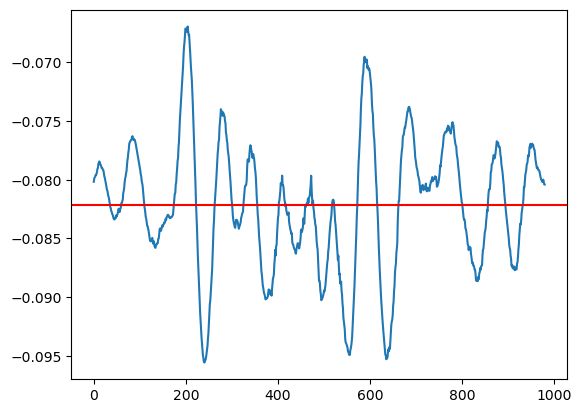

In [54]:
plt.plot((strained_dict['pressure_GPa'][20:] - relaxed_dict['pressure_GPa'][20:])[:,0,0])
plt.axhline(-mean_stress_diff_plain[0,0], color='red')

Smoothening

In [66]:
import numpy as np

def moving_average(x, w):
    # x: (nsteps, 3, 3)
    kernel = np.ones(w) / w
    return np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), 0, x)

skip = 20
w = 50
w2 = 100

dP = (strained_dict["pressure_GPa"][skip:] - relaxed_dict["pressure_GPa"][skip:])[:,0,0]
dP_w = moving_average(dP, w)
dP_w2 = moving_average(dP, w2)

# mean_stress_diff_moving_average = -np.mean(dP_s, axis=0)

In [69]:
dP_w

array([-0.0396087 , -0.04120952, -0.04281363, -0.04442295, -0.0460376 ,
       -0.04765485, -0.04927498, -0.05090049, -0.052529  , -0.05416076,
       -0.05579752, -0.05743865, -0.05908531, -0.06073419, -0.06238759,
       -0.06404232, -0.06570059, -0.06735993, -0.06902227, -0.07068801,
       -0.07235541, -0.07402302, -0.07568913, -0.07735301, -0.07901802,
       -0.08067842, -0.08073725, -0.08079884, -0.08086   , -0.08091784,
       -0.08097552, -0.08103487, -0.08109986, -0.08116568, -0.08123375,
       -0.08129979, -0.08136645, -0.08143464, -0.08150198, -0.08156561,
       -0.08161426, -0.08165894, -0.0816966 , -0.08172137, -0.08173982,
       -0.0817541 , -0.0817599 , -0.08176177, -0.08174987, -0.08172286,
       -0.08168832, -0.08164121, -0.08158593, -0.08151533, -0.08143709,
       -0.08135441, -0.08126796, -0.08117445, -0.08107665, -0.08097292,
       -0.08086186, -0.08075088, -0.08063632, -0.08051773, -0.08039596,
       -0.08027321, -0.08014988, -0.08002897, -0.07990957, -0.07

In [75]:
strained_dict.keys()

dict_keys(['positions', 'cell', 'forces', 'temperature', 'energy_pot', 'energy_tot', 'pressure', 'velocities', 'volume', 'pressure_GPa'])

In [80]:
strained_dict['temperature'][:] == relaxed_dict['temperature'][:]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [82]:
w_T = 100
T = strained_dict['temperature']
T_w = moving_average(T, w_T)

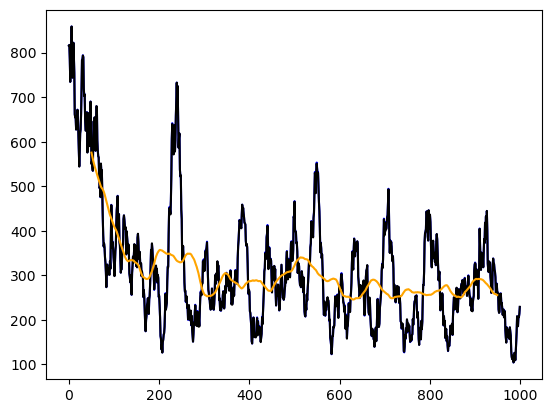

In [83]:
plt.plot((relaxed_dict['temperature'][:]), color='blue')
plt.plot((strained_dict['temperature'][:]), color='black')
plt.plot(range((w_T//2), len(T_w[(w_T//2):-(w_T//2)]) + (w_T//2)), T_w[(w_T//2):-(w_T//2)], color='orange')

Text(0, 0.5, 'Stress difference (GPa)')

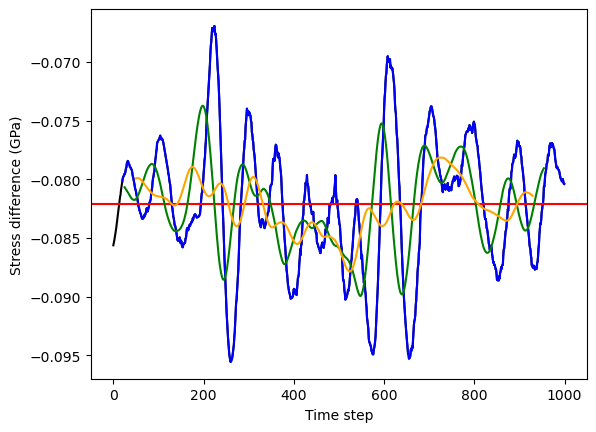

In [73]:
plt.plot((strained_dict['pressure_GPa'][:] - relaxed_dict['pressure_GPa'][:])[:,0,0], color='black')
plt.plot(range(20, len((strained_dict['pressure_GPa'][20:] - relaxed_dict['pressure_GPa'][20:])[:,0,0]) + 20), (strained_dict['pressure_GPa'][20:] - relaxed_dict['pressure_GPa'][20:])[:,0,0], color='blue')
plt.axhline(-mean_stress_diff_plain[0,0], color='red')
plt.plot(range((w//2), len(dP_w[(w//2):-(w//2)]) + (w//2)), dP_w[(w//2):-(w//2)], color='green')
plt.plot(range((w2//2), len(dP_w2[(w2//2):-(w2//2)]) + (w2//2)), dP_w2[(w2//2):-(w2//2)], color='orange')
plt.xlabel('Time step')
plt.ylabel('Stress difference (GPa)')



In [ ]:
min(dP_w2[(w2//2):-(w2//2)]), max(dP_w2[(w2//2):-(w2//2)])

(np.float64(-0.08786792810225955), np.float64(-0.078152546990977))

In [71]:
-min(dP_w2[(w2//2):-(w2//2)])+ max(dP_w2[(w2//2):-(w2//2)])

np.float64(0.009715381111282548)

In [ ]:
mean_stress_diff_moving_average

array([[ 8.11226935e-02, -1.15939307e-03, -5.60777896e-04],
       [-1.15939307e-03,  5.86813723e-02, -4.83067579e-05],
       [-5.60777896e-04, -4.83067579e-05,  5.88143148e-02]])

In [ ]:
plt.plot((dP)[:,0,0])
plt.axhline(-stress_diff_moving_average, color='red')

In [ ]:
tensor_dict = {}
for constant_str, deformation_gradient in deformation_gradient_dict.items():
    diff, relaxed_dict, strained_dict = get_stress_tensor_at_finite_temperature(
        structure=equilibriated_structure, 
        potential_dataframe=potential_df,
        deformation_gradient=deformation_gradient,
        temperature=500,
        run=run,
        thermo=thermo,
        seed=seed,
        thermostat=thermostat
    )
    
    tensor_dict[constant_str] = diff
    tensor_dict[f'relaxed_dict_{constant_str}'] = relaxed_dict
    tensor_dict[f'strained_dict_{constant_str}'] = strained_dict


In [ ]:

elastic_constants_list = get_elastic_constants_from_stress_tensor(
    tensor_dict=tensor_dict, 
    strain=strain
)

return {"elastic_constants": elastic_constants_list, "tensor_dict": tensor_dict}